In [27]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

from utils import multi_hot_encode, prepare_recommender_data, load_loss_val

RANDOM_STATE = 36
SEED = 1234

# 1. Importing Data

In [28]:
movies = pd.read_csv('./MovieLens/movies.csv')
ratings = pd.read_csv('./MovieLens/ratings.csv')

print(movies.shape, ratings.shape)
print(movies.columns, ratings.columns)

(9742, 3) (100836, 4)
Index(['movieId', 'title', 'genres'], dtype='str') Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')


In [29]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [30]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


# 2. Encoding Genres Column

In [31]:
genres = [
    "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir",
    "Horror", "IMAX", "Musical", "Mystery", "Romance",
    "Sci-Fi", "Thriller", "War", "Western"
]
genre_col = movies['genres']

encoded_columns = multi_hot_encode(genres, genre_col)

movies['genres_encoded'] = encoded_columns


# Mergrin encoded Gernes to Ratings DataFrame

In [32]:
ratings = ratings.merge(
    movies[['movieId', 'genres_encoded']], # Columns
    how='left', # Ratings is the main Df
    on='movieId' # Match based on movieId column
)

# Dropping TimeStamp Column

In [33]:
ratings = ratings.drop('timestamp', axis=1)

In [34]:
ratings

,userId,movieId,rating,genres_encoded
0,1,1,4.0,"[0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
1,1,3,4.0,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
2,1,6,4.0,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1,47,5.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
4,1,50,5.0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...
100831,610,166534,4.0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, ..."
100832,610,168248,5.0,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
100833,610,168250,5.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
100834,610,168252,5.0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


# Train/Validation Splitting Data

In [35]:
train_data , cv_data = train_test_split(ratings, test_size=0.2, random_state=RANDOM_STATE)

print(train_data.shape, cv_data.shape)
cv_data.head()

(80668, 4) (20168, 4)


,userId,movieId,rating,genres_encoded
43714,292,4643,3.0,"[1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
40452,274,59604,3.5,"[0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, ..."
93719,599,3735,3.0,"[0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
63442,414,3535,4.0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, ..."
60720,391,3717,2.0,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


# Preparing Recommender NN Data

In [36]:
X_user_train, y_train, X_movie_train, train_movie_ids, X_user_cv, X_movie_cv, y_cv, cv_movie_ids = prepare_recommender_data(train_data, cv_data)

X_user_train.shape, y_train.shape, X_movie_train.shape, train_movie_ids.shape, X_user_cv.shape, X_movie_cv.shape, y_cv.shape, cv_movie_ids.shape

((80668,),
 (80668,),
 (80668, 19),
 (80668,),
 (20168,),
 (20168, 19),
 (20168,),
 (20168,))

---
# Creating Network

In [37]:
num_users = np.unique(X_user_train).shape[0] # 610

tf.random.set_seed(SEED)

l2_lambda = tf.keras.regularizers.l2(0.001)

# User Features Model
user_NN = tf.keras.models.Sequential([
    
    tf.keras.Input(shape=(1,), dtype=tf.float32),
    
    tf.keras.layers.Embedding(
        input_dim=num_users+1,
        output_dim=32,
        embeddings_regularizer=l2_lambda
    ),
    tf.keras.layers.Flatten()
], name='user_model')

# Movie Features Model
movie_NN = tf.keras.models.Sequential([
    
    tf.keras.Input(shape=(19,), dtype=tf.float32),
    
    Dense(256, activation='relu', name='movieL1', kernel_regularizer=l2_lambda),
    Dense(128, activation='relu', name='movieL2', kernel_regularizer=l2_lambda),
    Dense(32, activation='linear', name='movieL3', kernel_regularizer=l2_lambda),
], name='movie_model')

# Symbolic user input
user_input = tf.keras.Input(shape=(1,), dtype=tf.float32)
# Symbolic answer of the model
vu = user_NN(user_input)

# Symbolic output: 32-dimensional user embedding
movie_input = tf.keras.Input(shape=(19,), dtype=tf.float32)
# Symbolic output: 32-dimensional movie representation
vm = movie_NN(movie_input)

# Calc Dot Product of the answer from the two models
output = tf.keras.layers.Dot(axes=1, name='dot_product')([vu, vm])

# Link the two Models and their output togehter so they are one trainable keras model
model = tf.keras.Model([user_input, movie_input], output)

In [38]:
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_model          │ (None, 32)        │     19,552 │ input_layer_17[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_model         │ (None, 32)        │     42,144 │ input_layer_18[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1)         │          0 │ user_model[0][0], │
│                     │                   │            │ movie_model[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,696 (241.00 KB)

 Trainable params: 61,696 (241.00 KB)

 Non-trainable params: 0 (0.00 B)

# Compile & Fit

In [39]:
model = tf.keras.models.load_model('./Models/movie_recommender_pro2.keras')


#? Since it took me 6 minutes to train the model im just gonna load the saved model

# model.compile(
#     optimizer = tf.keras.optimizers.Adam(0.001),
#     loss = tf.keras.losses.MeanSquaredError()
# )

# history = model.fit(
#     [X_user_train.reshape(-1, 1), X_movie_train], y_train,
#     validation_data=([X_user_cv.reshape(-1, 1), X_movie_cv], y_cv),
#     epochs=20)

# Plotting Trianing and Val Loss 

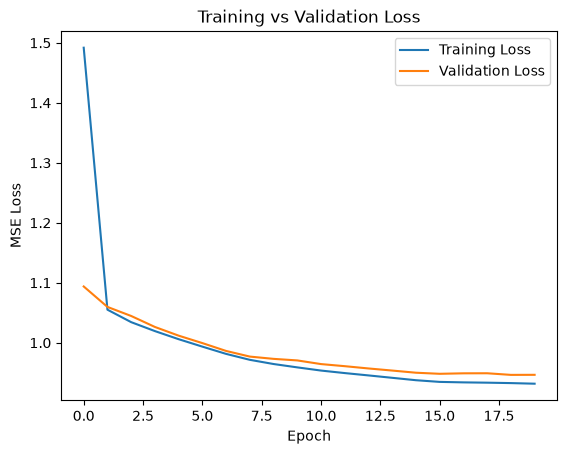

In [40]:
#? The loss & validation loss i got from training the model
loss, val_loss = load_loss_val()

plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

In [41]:
class MovieRecommender(tf.keras.Model):
    
    def __init__(self, num_users, num_movie_features=19, embedding_dim=32, l2_lambda=0.001):
        super().__init__()
        self.num_users = num_users
        self.num_movie_features = num_movie_features
        self.embedding_dim = embedding_dim
        self.l2_lambda = tf.keras.regularizers.l2(l2_lambda)

        # -------------------------
        # User Network
        # -------------------------

        self.user_NN = tf.keras.models.Sequential([
            
            tf.keras.Input(shape=(1,), dtype=tf.float32),
            
            tf.keras.layers.Embedding(
                input_dim=num_users+1,
                output_dim=embedding_dim,
                embeddings_regularizer=self.l2_lambda
            ),
            tf.keras.layers.Flatten()
        ], name='user_model')

        # -------------------------
        # Movie Network
        # -------------------------
        self.movie_NN = tf.keras.models.Sequential([
            
            tf.keras.Input(shape=(num_movie_features,), dtype=tf.float32),
            
            Dense(256, activation='relu', name='movieL1', kernel_regularizer=self.l2_lambda),
            Dense(128, activation='relu', name='movieL2', kernel_regularizer=self.l2_lambda),
            Dense(embedding_dim, activation='linear', name='movieL3', kernel_regularizer=self.l2_lambda),
        ], name='movie_model')
        
        # -------------------------
        # Dot Product
        # -------------------------
        self.dot_product = tf.keras.layers.Dot(axes=1, name='dot_product')

    def call(self, inputs):
        
        user_input, movie_input = inputs
            
        # Actual output of the model
        vu = self.user_NN(user_input)

        # Actual output: 32-dimensional movie representation
        vm = self.movie_NN(movie_input)

        # Calc Dot Product of the output from the two models
        output = self.dot_product([vu, vm])

        return output    
    
    def get_config(self):

        config = super().get_config()

        config.update({
            "num_users": self.num_users,
            "num_movie_features": self.num_movie_features,
            "embedding_dim": self.embedding_dim,
            "l2_lambda": self.l2_lambda
        })

        return config

In [ ]:
num_users = np.unique(X_user_train).shape[0] # 610
model = MovieRecommender(num_users=num_users)

model.compile(
    optimizer = tf.keras.optimizers.Adam(0.001),
    loss = tf.keras.losses.MeanSquaredError()
)

history = model.fit(
    [X_user_train.reshape(-1, 1), X_movie_train], y_train,
    validation_data=([X_user_cv.reshape(-1, 1), X_movie_cv], y_cv),
    epochs=20)


Epoch 1/20


W0000 00:00:1785690390.839352   22117 cpu_allocator_impl.cc:82] Allocation of 12261536 exceeds 10% of free system memory.


2521/2521 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 1.4981 - val_loss: 1.0954
Epoch 2/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 1.0557 - val_loss: 1.0583
Epoch 3/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 1.0350 - val_loss: 1.0430
Epoch 4/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 1.0232 - val_loss: 1.0319
Epoch 5/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 1.0119 - val_loss: 1.0180
Epoch 6/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 1.0017 - val_loss: 1.0077
Epoch 7/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.9928 - val_loss: 0.9997
Epoch 8/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.9854 - val_loss: 0.9923
Epoch 9/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.9779 - val_loss: 0.9856
Epoch 10/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.9702 - val_loss: 0.9769
Epoch 11/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.9630 - val_loss: 0.9711
Epoch 12/20
2521/2521 ━━━━━━━━